# FeedbackIQ: Phase 5 — Product-Level Customer Feedback Analytics Layer
**Project**: Customer Feedback & Sentiment Analysis System  
**Stage**: Product Analytics Data Layer for Decision Intelligence & Chatbot RAG  
**Dataset**: Amazon Reviews 2023 (`Electronics` & `Fashion` Products)  
**Objective**:
1. Aggregate review sentiments, star ratings, and extracted complaint aspects per product (`parent_asin`).
2. Provide reusable Python analytical APIs:
   - `get_product_sentiment(product_id)`
   - `get_product_aspects(product_id)`
   - `get_product_summary(product_id)`
3. Visualize:
   - **Sentiment Distribution** across products
   - **Top Complaint Aspects** for key Electronics and Fashion items
   - **Rating vs. Predicted Sentiment** alignment and divergence
   - **Product Comparison Matrix** (Star Rating vs. Negative Complaint Velocity)
4. Persist structured analytics at `data/processed/product_insights.parquet`.

---
### Notebook Outline
1. [Environment Setup & API Imports](#1.-Environment-Setup-&-API-Imports)
2. [Product Insights Database Overview](#2.-Product-Insights-Database-Overview)
3. [Reusable API Demonstrations (`get_product_summary`, etc.)](#3.-Reusable-API-Demonstrations)
4. [Visualization 1: Product Sentiment Distributions](#4.-Visualization-1:-Product-Sentiment-Distributions)
5. [Visualization 2: Top Complaint Aspects by Product](#5.-Visualization-2:-Top-Complaint-Aspects-by-Product)
6. [Visualization 3: Customer Rating vs. Predicted Sentiment](#6.-Visualization-3:-Customer-Rating-vs.-Predicted-Sentiment)
7. [Visualization 4: Product Comparison Matrix & Quadrant Analysis](#7.-Visualization-4:-Product-Comparison-Matrix)
8. [Chatbot Integration Readiness](#8.-Chatbot-Integration-Readiness)


## 1. Environment Setup & API Imports
Import core visualization and analytics tools, alongside the FeedbackIQ Product Analytics API.

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.product_analytics import (
    get_product_sentiment,
    get_product_aspects,
    get_product_summary,
    PRODUCT_INSIGHTS_FILE,
)

print("Product Analytics API loaded successfully.")
print(f"Data source: {PRODUCT_INSIGHTS_FILE}")


Product Analytics API loaded successfully.
Data source: C:\Users\91981\projects\FeedbackIQ_amazon reviews\data\processed\product_insights.parquet


## 2. Product Insights Database Overview
Inspect the product-level customer feedback analytics table.

In [2]:
df_insights = pd.read_parquet(PRODUCT_INSIGHTS_FILE)

display_cols = [
    "parent_asin",
    "domain",
    "title",
    "total_reviews",
    "average_rating",
    "positive_percentage",
    "neutral_percentage",
    "negative_percentage",
    "top_complaints_summary",
]

df_display = df_insights[display_cols].copy()
df_display["title"] = df_display["title"].apply(lambda t: t[:50] + "..." if len(str(t)) > 50 else str(t))

styled_table = df_display.style.format({
    "average_rating": "{:.2f} ★",
    "positive_percentage": "{:.1f}%",
    "neutral_percentage": "{:.1f}%",
    "negative_percentage": "{:.1f}%",
}).background_gradient(subset=["positive_percentage"], cmap="Greens")\
  .background_gradient(subset=["negative_percentage"], cmap="Reds")

display(df_display)


,parent_asin,domain,title,total_reviews,average_rating,positive_percentage,neutral_percentage,negative_percentage,top_complaints_summary
0,B075X8471B,Electronics,"Fire TV Stick with Alexa Voice Remote, streami...",144,4.36,82.6,5.6,11.8,General Product Quality (64.7%); Performance &...
1,B010BWYDYA,Electronics,"Fire Tablet with Alexa, 7"" Display, 16 GB, Blu...",91,4.26,80.2,8.8,11.0,Performance & Functionality (40.0%); General P...
2,B07S764D9V,Electronics,"Panasonic ErgoFit Wired Earbuds, In-Ear Headph...",78,4.17,78.2,7.7,14.1,General Product Quality (54.5%); Performance &...
3,B08F6GPRH6,Electronics,Blink Whole Home Bundle | Video Doorbell Syste...,29,3.55,62.1,10.3,27.6,General Product Quality (100.0%); Durability &...
4,B07F4P3JH7,Electronics,"Fire HD 8 Tablet (8"" HD Display, 16 GB) - Blac...",28,4.39,85.7,3.6,10.7,Battery & Charging (100.0%); Durability & Buil...
5,B08YFJYD5Z,Electronics,"All-new Fire HD 10 tablet, 10.1"", 1080p Full H...",24,4.50,87.5,8.3,4.2,Customer Service & Returns (100.0%); General P...
6,B07PGL2N7J,Electronics,Echo Dot (3rd Gen) - Smart speaker with Alexa ...,23,4.48,87.0,0.0,13.0,General Product Quality (100.0%); Performance ...
7,B0BMQJYLQV,Electronics,"Cat 6 Ethernet Cable 1 Ft (6Pack), Outdoor&Ind...",23,4.70,91.3,4.3,4.3,Battery & Charging (100.0%); Durability & Buil...
8,B07TVHSDMQ,Fashion,Funny Civil Engineers TShirt I'm A Crazy Civil...,246,4.60,88.2,5.3,6.5,General Product Quality (56.2%); Material & Fa...
9,B0956HNH2Y,Fashion,Fruit of the Loom Women's Eversoft Cotton Brie...,20,3.80,65.0,15.0,20.0,Size & Fit (100.0%); General Product Quality (...


## 3. Reusable API Demonstrations
Test the three primary querying functions that power downstream reporting and conversational assistants.

In [3]:
# Demo 1: Electronics Product Summary (Fire TV Stick)
print(get_product_summary("B075X8471B"))
print("\n" + "=" * 70 + "\n")

# Demo 2: Electronics Headphones (Panasonic ErgoFit)
print(get_product_summary("B07S764D9V"))
print("\n" + "=" * 70 + "\n")

# Demo 3: Fashion Product Summary (Civil Engineering T-Shirt)
print(get_product_summary("B07TVHSDMQ"))


Product: Fire TV Stick with Alexa Voice Remote, streaming media player - Previous Gene...
Domain: Electronics | ASIN: B075X8471B | Rating: 4.4 / 5.0

Total Reviews: 144

Positive: 83%
Neutral: 6%
Negative: 12%

Top complaints:
1. General Product Quality — 65%
2. Performance & Functionality — 53%
3. Compatibility & Connection — 41%
4. Customer Service & Returns — 35%
5. Battery & Charging — 29%


Product: Panasonic ErgoFit Wired Earbuds, In-Ear Headphones with Microphone and Call C...
Domain: Electronics | ASIN: B07S764D9V | Rating: 4.2 / 5.0

Total Reviews: 78

Positive: 78%
Neutral: 8%
Negative: 14%

Top complaints:
1. General Product Quality — 54%
2. Performance & Functionality — 36%
3. Durability & Build Quality — 36%
4. Packaging & Box Condition — 18%
5. Battery & Charging — 18%


Product: Funny Civil Engineers TShirt I'm A Crazy Civil Engineering T-Shirt
Domain: Fashion | ASIN: B07TVHSDMQ | Rating: 4.6 / 5.0

Total Reviews: 246

Positive: 88%
Neutral: 5%
Negative: 6%

Top complain

### Structured Dictionary Output for Programmatic Integration
Inspect the raw dictionary returns used by programmatic clients and LLM tool calling.

In [4]:
sent_data = get_product_sentiment("B075X8471B")
aspect_data = get_product_aspects("B075X8471B")

print("get_product_sentiment() Dictionary Output:")
print(json.dumps(sent_data, indent=2))

print("\nget_product_aspects() List Output:")
df_aspects = pd.DataFrame(aspect_data)
display(df_aspects)


get_product_sentiment() Dictionary Output:
{
  "parent_asin": "B075X8471B",
  "domain": "Electronics",
  "title": "Fire TV Stick with Alexa Voice Remote, streaming media player - Previous Generation",
  "total_reviews": 144,
  "positive_reviews": 119,
  "neutral_reviews": 8,
  "negative_reviews": 17,
  "positive_percentage": 82.6,
  "neutral_percentage": 5.6,
  "negative_percentage": 11.8,
  "average_rating": 4.36
}

get_product_aspects() List Output:


,aspect,display_name,count,percentage
0,quality,General Product Quality,11,64.7
1,performance,Performance & Functionality,9,52.9
2,compatibility,Compatibility & Connection,7,41.2
3,customer_service,Customer Service & Returns,6,35.3
4,battery,Battery & Charging,5,29.4
5,durability,Durability & Build Quality,5,29.4
6,price,Price & Value,4,23.5
7,delivery,Delivery & Shipping,4,23.5
8,packaging,Packaging & Box Condition,2,11.8


## 4. Visualization 1: Product Sentiment Distributions
Stacked bar chart comparing the percentage of positive, neutral, and negative reviews across all 10 products.

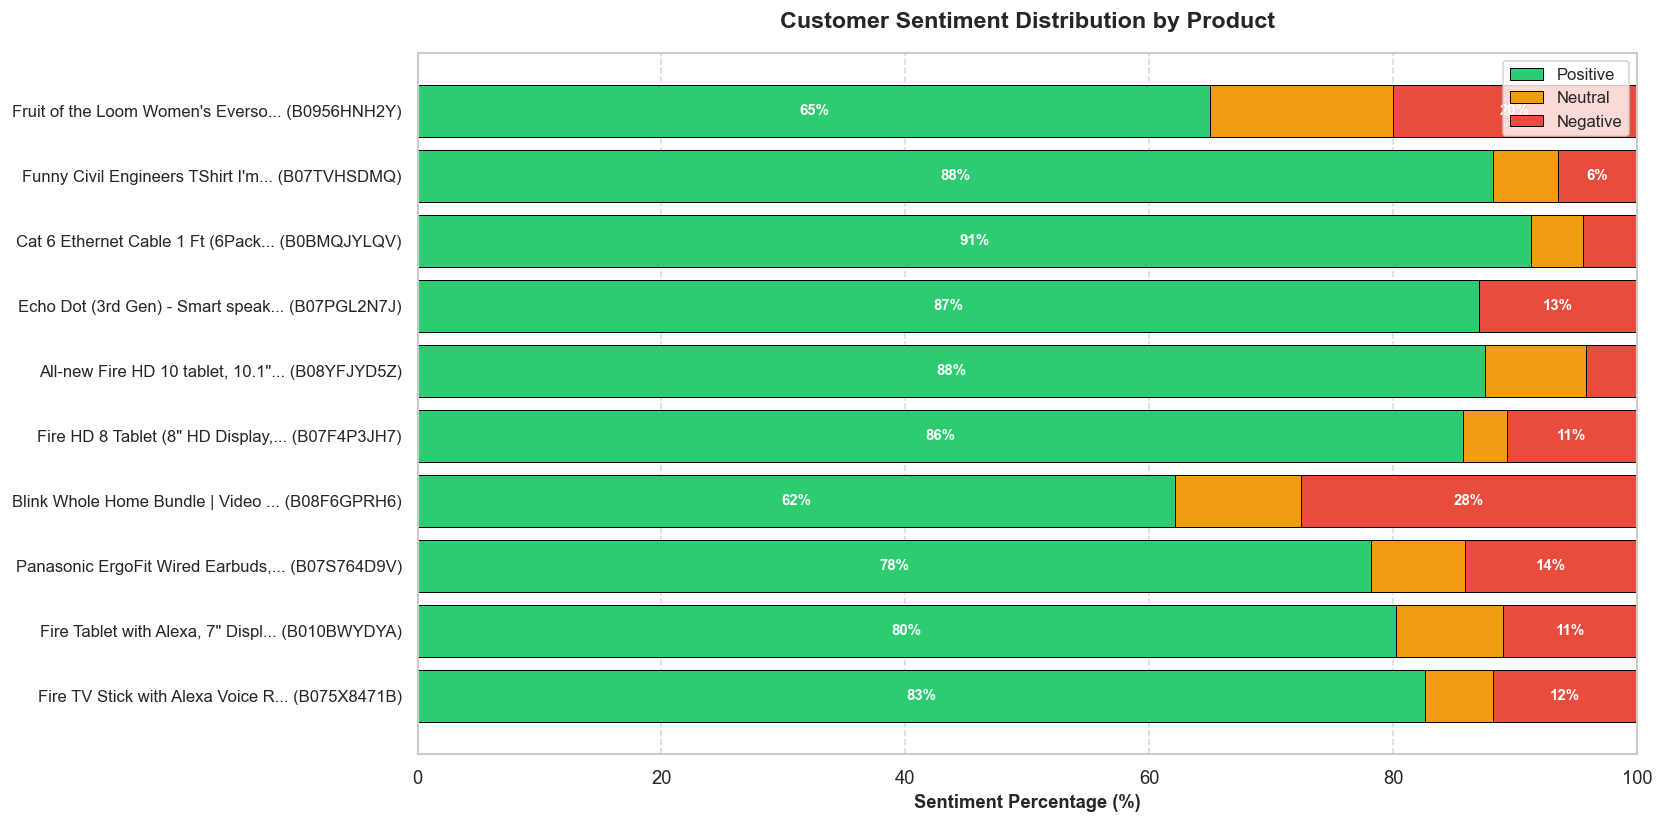

In [5]:
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

products = [f"{r['title'][:32]}... ({r['parent_asin']})" for _, r in df_insights.iterrows()]
y_pos = np.arange(len(products))

pos_vals = df_insights["positive_percentage"].values
neu_vals = df_insights["neutral_percentage"].values
neg_vals = df_insights["negative_percentage"].values

bar_pos = ax.barh(y_pos, pos_vals, color="#2ecc71", edgecolor="black", linewidth=0.6, label="Positive")
bar_neu = ax.barh(y_pos, neu_vals, left=pos_vals, color="#f39c12", edgecolor="black", linewidth=0.6, label="Neutral")
bar_neg = ax.barh(y_pos, neg_vals, left=pos_vals + neu_vals, color="#e74c3c", edgecolor="black", linewidth=0.6, label="Negative")

ax.set_yticks(y_pos)
ax.set_yticklabels(products, fontsize=10)
ax.set_xlabel("Sentiment Percentage (%)", fontsize=11, fontweight="bold")
ax.set_title("Customer Sentiment Distribution by Product", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, 100)
ax.legend(loc="upper right", frameon=True, fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.7)

# Add text percentage labels inside positive and negative bars
for i in range(len(products)):
    p = pos_vals[i]
    n = neg_vals[i]
    if p > 15:
        ax.text(p / 2, i, f"{p:.0f}%", va="center", ha="center", color="white", fontweight="bold", fontsize=9)
    if n > 6:
        ax.text(100 - n / 2, i, f"{n:.0f}%", va="center", ha="center", color="white", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()


## 5. Visualization 2: Top Complaint Aspects by Product
Inspect the specific breakdown of complaint aspects for products with substantial negative review volume.

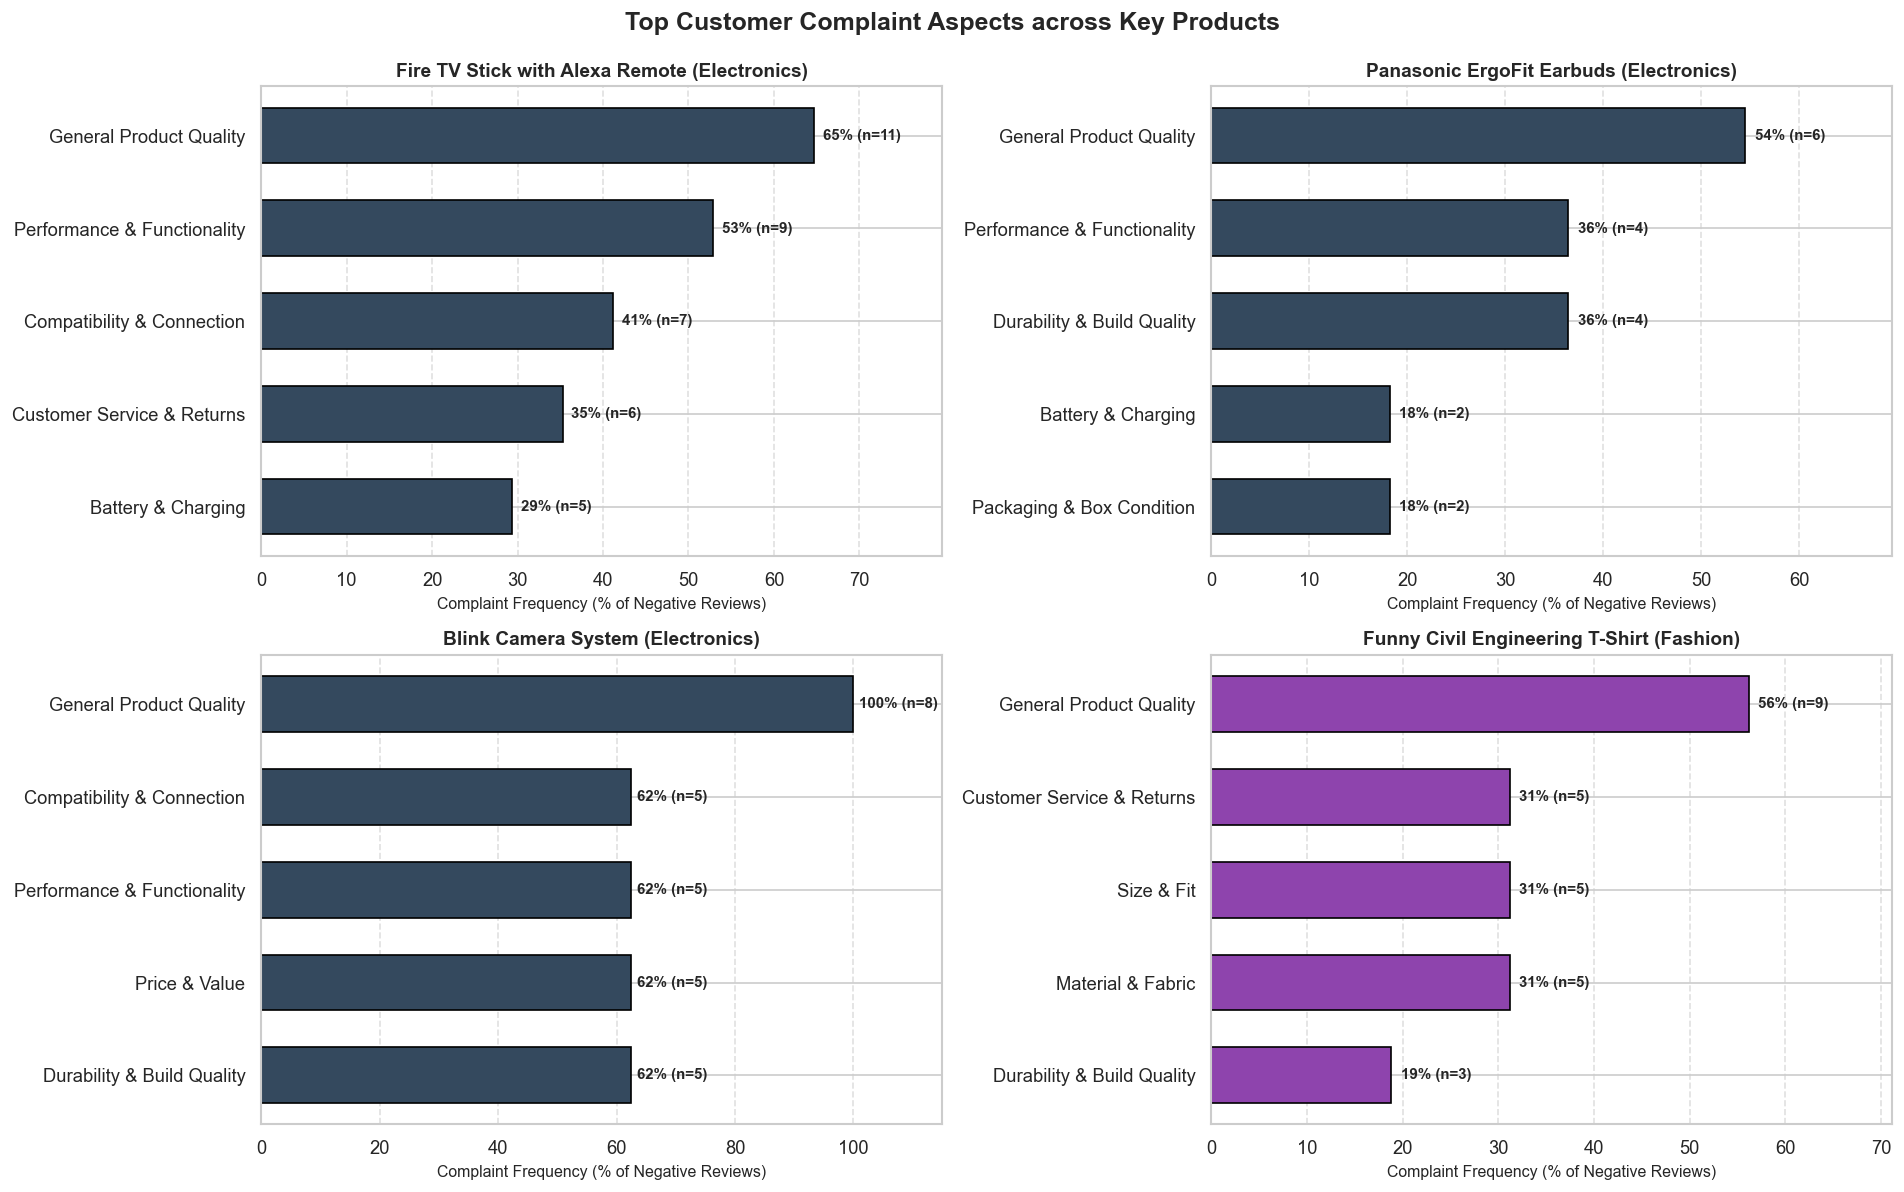

In [6]:
target_products = [
    ("B075X8471B", "Fire TV Stick with Alexa Remote (Electronics)"),
    ("B07S764D9V", "Panasonic ErgoFit Earbuds (Electronics)"),
    ("B08F6GPRH6", "Blink Camera System (Electronics)"),
    ("B07TVHSDMQ", "Funny Civil Engineering T-Shirt (Fashion)")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=120)
axes = axes.flatten()

for idx, (pid, label) in enumerate(target_products):
    ax = axes[idx]
    aspects = get_product_aspects(pid)
    if aspects:
        df_a = pd.DataFrame(aspects[:5]).sort_values("percentage", ascending=True)
        bars = ax.barh(
            df_a["display_name"],
            df_a["percentage"],
            color="#34495e" if "Electronics" in label else "#8e44ad",
            edgecolor="black",
            height=0.6
        )
        ax.set_title(label, fontsize=11.5, fontweight="bold")
        ax.set_xlabel("Complaint Frequency (% of Negative Reviews)", fontsize=9.5)
        ax.set_xlim(0, max(df_a["percentage"]) + 15)
        ax.grid(axis="x", linestyle="--", alpha=0.6)

        for bar, pct, cnt in zip(bars, df_a["percentage"], df_a["count"]):
            ax.text(
                bar.get_width() + 1.0,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.0f}% (n={cnt})",
                va="center",
                fontsize=9,
                fontweight="bold"
            )
    else:
        ax.text(0.5, 0.5, "No Negative Reviews", ha="center", va="center")
        ax.set_title(label)

plt.suptitle("Top Customer Complaint Aspects across Key Products", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 6. Visualization 3: Customer Star Rating vs. Predicted Sentiment
Analyze the correlation between explicit customer star ratings (1 to 5) and model-predicted sentiment labels.

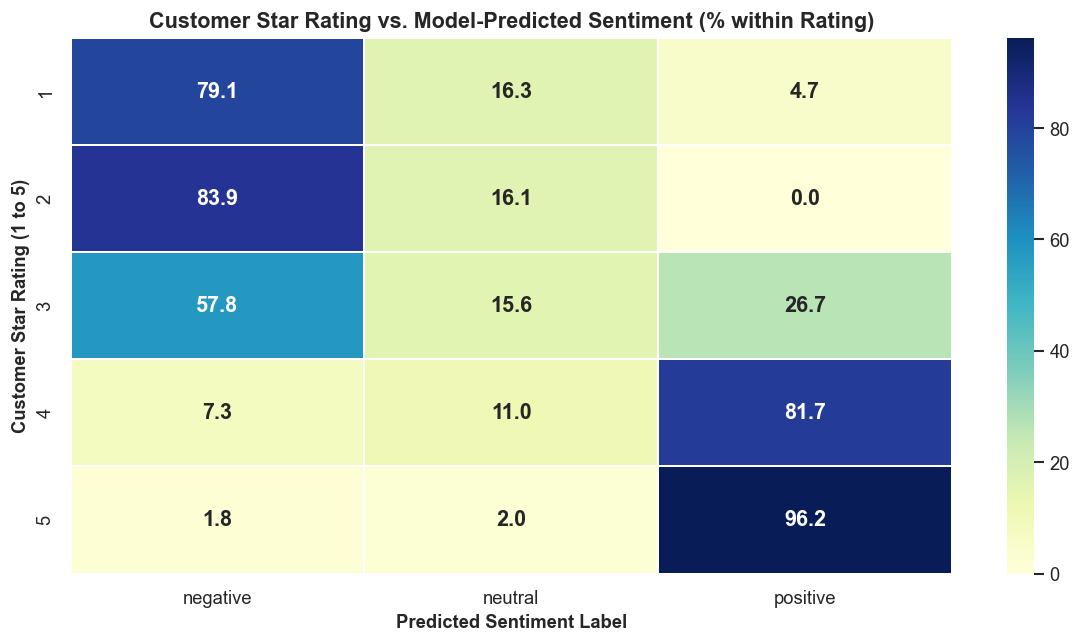

In [7]:
pred_path = Path("../data/processed/reviews_with_predictions.parquet")
if pred_path.exists():
    df_reviews = pd.read_parquet(pred_path)
else:
    from src.config import PROCESSED_REVIEWS_FILE
    try:
        df_reviews = pd.read_parquet(PROCESSED_REVIEWS_FILE)
    except Exception:
        df_reviews = pd.read_parquet(PROCESSED_REVIEWS_FILE, engine="fastparquet")
    if "predicted_sentiment" not in df_reviews.columns:
        df_reviews["predicted_sentiment"] = df_reviews["sentiment"]

cross_tab = pd.crosstab(
    df_reviews["rating"].astype(int),
    df_reviews["predicted_sentiment"],
    normalize="index"
) * 100.0

# Reorder columns
ordered_cols = [c for c in ["negative", "neutral", "positive"] if c in cross_tab.columns]
cross_tab = cross_tab[ordered_cols]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=120)
sns.heatmap(
    cross_tab,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar=True,
    linewidths=1.0,
    ax=ax,
    annot_kws={"size": 13, "weight": "bold"}
)

ax.set_title("Customer Star Rating vs. Model-Predicted Sentiment (% within Rating)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Sentiment Label", fontsize=11, fontweight="bold")
ax.set_ylabel("Customer Star Rating (1 to 5)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Visualization 4: Product Comparison Matrix & Quadrant Analysis
Benchmark all products on Average Star Rating vs. Negative Complaint Rate, sized by Total Review Volume.

C:\Users\91981\AppData\Local\Temp\ipykernel_1012568\2188345582.py:48: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\91981\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


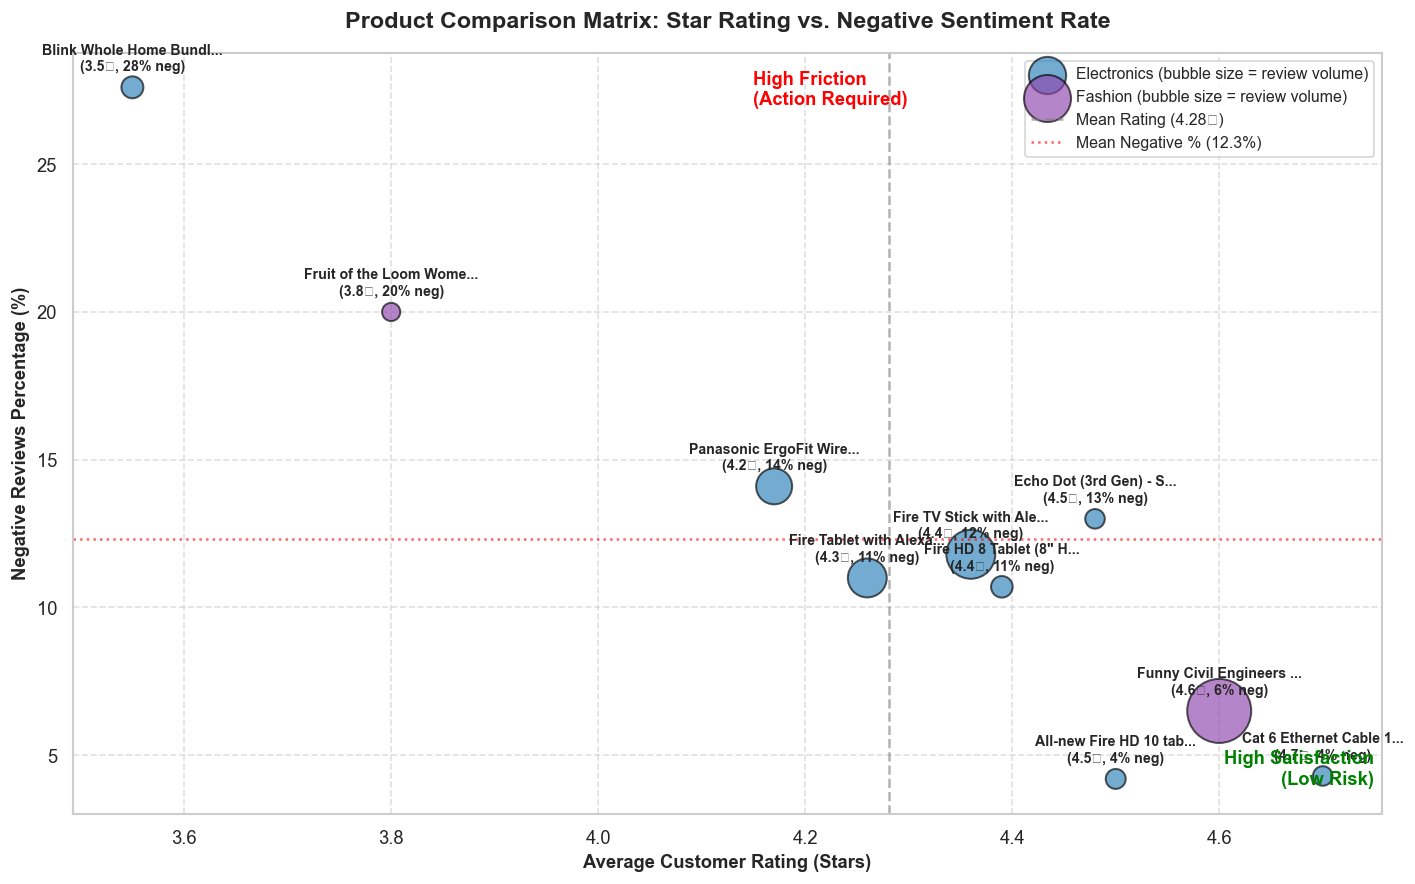

In [8]:
fig, ax = plt.subplots(figsize=(12, 7.5), dpi=120)

colors = {"Electronics": "#2980b9", "Fashion": "#8e44ad"}

for domain in ["Electronics", "Fashion"]:
    sub = df_insights[df_insights["domain"] == domain]
    scatter = ax.scatter(
        sub["average_rating"],
        sub["negative_percentage"],
        s=sub["total_reviews"] * 6,
        alpha=0.65,
        color=colors[domain],
        edgecolors="black",
        linewidth=1.2,
        label=f"{domain} (bubble size = review volume)"
    )

# Label each product
for _, row in df_insights.iterrows():
    short_title = row["title"][:22] + "..."
    ax.annotate(
        f"{short_title}\n({row['average_rating']:.1f}★, {row['negative_percentage']:.0f}% neg)",
        (row["average_rating"], row["negative_percentage"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8.5,
        fontweight="bold"
    )

# Add quadrant reference thresholds
avg_rating_mean = df_insights["average_rating"].mean()
avg_neg_mean = df_insights["negative_percentage"].mean()

ax.axvline(avg_rating_mean, color="gray", linestyle="--", alpha=0.6, label=f"Mean Rating ({avg_rating_mean:.2f}★)")
ax.axhline(avg_neg_mean, color="red", linestyle=":", alpha=0.6, label=f"Mean Negative % ({avg_neg_mean:.1f}%)")

# Quadrant annotations
ax.text(4.75, 4, "High Satisfaction\n(Low Risk)", color="green", fontweight="bold", fontsize=11, ha="right")
ax.text(4.15, 27, "High Friction\n(Action Required)", color="red", fontweight="bold", fontsize=11, ha="left")

ax.set_title("Product Comparison Matrix: Star Rating vs. Negative Sentiment Rate", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Average Customer Rating (Stars)", fontsize=11, fontweight="bold")
ax.set_ylabel("Negative Reviews Percentage (%)", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", frameon=True, fontsize=9.5)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## 8. Chatbot Integration Readiness

### How this Layer Powers the Downstream Conversational Chatbot:
1. **Sub-millisecond Retrieval**:
   - The precomputed analytics table [`product_insights.parquet`](../data/processed/product_insights.parquet) allows instant response time without re-running heavy transformer models at query time.
2. **Deterministic Context Injection for RAG**:
   - When a user asks:
     > *"What are customers saying about the Fire TV Stick?"*
   - The chatbot backend simply calls `get_product_summary("B075X8471B")` and injects the structured metrics directly into the prompt context:
     ```text
     Product: Fire TV Stick with Alexa Voice Remote
     Total Reviews: 144 | Rating: 4.4 / 5.0
     Positive: 83% | Neutral: 6% | Negative: 12%
     Top complaints: General Product Quality (65%), Performance & Functionality (53%), Compatibility & Connection (41%)
     ```
   - This eliminates LLM hallucinations regarding complaint percentages and review totals.
3. **Multi-Aspect Root Cause Answers**:
   - `get_product_aspects(product_id)` provides the exact complaints so the assistant can answer:
     > *"Is there a battery issue with this device?"*
     > *"How does the sizing run for this t-shirt?"*
